Linear Fit:
m = 0.004697270093030349
b = 1.9202562147323465
RMSE = 10.048978786575406

Linear Fit without COVID:
m = -0.001906988188976378
b = 2.194285187007874
RMSE = 1.4431864883291987

Polynomial Fit:
coeff = [ 2.11403340e-01  4.12733208e-01 -2.11036921e-02  3.57892276e-04
 -1.71060095e-06]
MSE = 100.629802089818
R2 = 0.0035410151185395478
RMSE = 10.031440678677116

Spline Fit:
MSE = 2.258152859794034e-30
R2 = 1.0
RMSE = 1.5027151625620985e-15

Residuals:
[ -0.22495348  -1.84374257   0.33746835   0.71867927  -0.30010981
   2.99049565   0.97640384  -0.53768797   1.45291749  -0.25177978
  -0.75647705   0.42473387   1.00594479  -7.21284429 -30.21754156
  31.67776117   4.16836663  -3.75042245   0.2260912    1.11669666]

Max Residual: 31.677761171267345 at index 15
Min Residual: -30.217541558639624 at index 14

Big-O:
Linear: O(n)
Polynomial: O(n d^2 + d^3)
Spline: O(n)


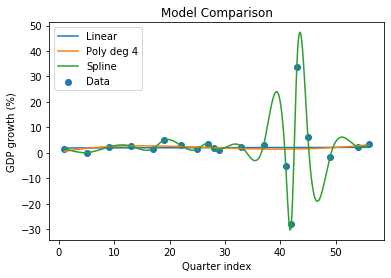

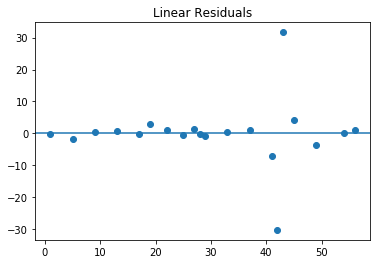

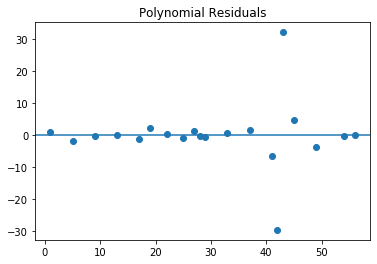

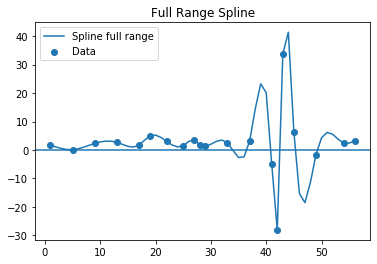

In [16]:
import numpy as np
import matplotlib.pyplot as plt


#GDP Growth Rate Data

quarter_labels = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1",
    "2014 Q3", "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4",
    "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2",
    "2020 Q3", "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"
]

gdp = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3
], dtype=float)


def quarter_to_index(label):
    parts = label.split()
    year = int(parts[0])
    quarter = int(parts[1][1])
    return (year - 2010) * 4 + quarter


x = np.array([quarter_to_index(label) for label in quarter_labels], dtype=float)
y = gdp.copy()
full_x = np.arange(1, 57, dtype=float)


#Least Squares Algorithm

n = len(x)

sumx = np.sum(x)
sumy = np.sum(y)
sumx2 = np.sum(x * x)
sumxy = np.sum(x * y)

m = (n * sumxy - sumx * sumy) / (n * sumx2 - sumx**2)
b = (sumy - m * sumx) / n

yp = m * x + b
residuals = y - yp

linear_rmse = np.sqrt(np.mean((y - yp) ** 2))

max_res = np.max(residuals)
min_res = np.min(residuals)

max_index = np.argmax(residuals)
min_index = np.argmin(residuals)


#Linear Fit without the COVID data

covid = {"2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1"}
mask = np.array([label not in covid for label in quarter_labels])

x_nc = x[mask]
y_nc = y[mask]

n_nc = len(x_nc)

sumx_nc = np.sum(x_nc)
sumy_nc = np.sum(y_nc)
sumx2_nc = np.sum(x_nc * x_nc)
sumxy_nc = np.sum(x_nc * y_nc)

m_nc = (n_nc * sumxy_nc - sumx_nc * sumy_nc) / (n_nc * sumx2_nc - sumx_nc**2)
b_nc = (sumy_nc - m_nc * sumx_nc) / n_nc

y_nc_line = m_nc * x_nc + b_nc
linear_rmse_nc = np.sqrt(np.mean((y_nc - y_nc_line) ** 2))


#Polynomial Fitting

degree = 4
V = np.vander(x, degree + 1, increasing=True)
coeff_v = np.linalg.lstsq(V, y, rcond=None)[0]
y_v = V @ coeff_v


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


poly_mse = mse(y, y_v)
poly_r2 = r2(y, y_v)
poly_rmse = np.sqrt(poly_mse)


def eval_poly(coeff, x_eval):
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(len(coeff)):
        y_eval += coeff[i] * x_eval**i

    return y_eval


#Cubic Spline Algorithm

def spline_coeffs(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n)
    B = np.zeros(n)
    C = np.zeros(n)
    D = np.zeros(n)

    B[0] = 1
    B[-1] = 1
    D[0] = 0
    D[-1] = 0

    for i in range(1, n - 1):
        A[i] = h[i - 1] / 6
        B[i] = (h[i - 1] + h[i]) / 3
        C[i] = h[i] / 6
        D[i] = (y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1]

    #Thomas Algorithm
    for i in range(1, n):
        w = A[i] / B[i - 1]
        B[i] = B[i] - w * C[i - 1]
        D[i] = D[i] - w * D[i - 1]

    #Back substitution
    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M


def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    y_eval = []

    for xe in x_eval:
        if xe <= x[0]:
            i = 0
        elif xe >= x[-1]:
            i = n - 2
        else:
            for j in range(n - 1):
                if x[j] <= xe <= x[j + 1]:
                    i = j
                    break

        h = x[i + 1] - x[i]

        t1 = M[i] * (x[i + 1] - xe)**3 / (6 * h)
        t2 = M[i + 1] * (xe - x[i])**3 / (6 * h)
        t3 = (y[i] / h - M[i] * h / 6) * (x[i + 1] - xe)
        t4 = (y[i + 1] / h - M[i + 1] * h / 6) * (xe - x[i])

        y_eval.append(t1 + t2 + t3 + t4)

    return np.array(y_eval)


M = spline_coeffs(x, y)
y_spline = evaluate_spline(x, y, M, x)

spline_mse = mse(y, y_spline)
spline_r2 = r2(y, y_spline)
spline_rmse = np.sqrt(spline_mse)


#Smooth x-values for plots

x_eval = np.linspace(x[0], x[-1], 500)
y_line = m * x_eval + b
y_poly = eval_poly(coeff_v, x_eval)
y_spline_curve = evaluate_spline(x, y, M, x_eval)

full_spline = evaluate_spline(x, y, M, full_x)


#Printing Numerical Results

print("Linear Fit:")
print("m =", m)
print("b =", b)
print("RMSE =", linear_rmse)

print("\nLinear Fit without COVID:")
print("m =", m_nc)
print("b =", b_nc)
print("RMSE =", linear_rmse_nc)

print("\nPolynomial Fit:")
print("coeff =", coeff_v)
print("MSE =", poly_mse)
print("R2 =", poly_r2)
print("RMSE =", poly_rmse)

print("\nSpline Fit:")
print("MSE =", spline_mse)
print("R2 =", spline_r2)
print("RMSE =", spline_rmse)

print("\nResiduals:")
print(residuals)

print("\nMax Residual:", max_res, "at index", max_index)
print("Min Residual:", min_res, "at index", min_index)

print("\nBig-O:")
print("Linear: O(n)")
print("Polynomial: O(n d^2 + d^3)")
print("Spline: O(n)")


#Plots

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_eval, y_line, label="Linear")
plt.plot(x_eval, y_poly, label="Poly deg 4")
plt.plot(x_eval, y_spline_curve, label="Spline")
plt.xlabel("Quarter index")
plt.ylabel("GDP growth (%)")
plt.title("Model Comparison")
plt.legend()
plt.show()

plt.figure()
plt.scatter(x, residuals)
plt.axhline(0)
plt.title("Linear Residuals")
plt.show()

plt.figure()
plt.scatter(x, y - y_v)
plt.axhline(0)
plt.title("Polynomial Residuals")
plt.show()

plt.figure()
plt.scatter(x, y, label="Data")
plt.axhline(0)
plt.plot(full_x, full_spline, label="Spline full range")
plt.title("Full Range Spline")
plt.legend()
plt.show()

**Introduction**

In this project, I analyzed U.S. quarterly GDP growth rates from 2010 to 2023 using three different methods: linear least squares, a degree-4 polynomial fit, and a natural cubic spline. I used simple integer values (1, 2, 3, …) to represent each quarter. The goal was to compare how these methods behave, both visually and numerically, and understand when each one is useful.


**Part A: Cubic Spline Interpolation**

To build the cubic spline, I solved for the second derivatives at each data point, which are stored in the array M in the code. If there are (n) data points, then there are (n) values to solve for. The spline is made of multiple cubic functions, with one between each pair of data points.

At every interior data point, the spline is forced to be smooth. This means that:
1.) The function connects (no gaps)
2.) The first derivative matches(no sharper corners)
3.) The second derivative matches (the smooth curve)

These conditions create a system of equations that can be solved using a tridiagonal matrix, which I solved using the Thomas algorithm.

Because this is a natural spline, the second derivative at the first and last data points is equal to zero. This keeps the ends from bending as much.

After computing the spline, I evaluated it across the full range of the quarters and plotted it. The result line is a smooth curve that passes exactly through all the data points. This makes the spline a good method when we want to estimate values between known data points.

One important point is the extreme value at 2020 Q2, where we are given −28.1%. Since the spline has to pass exactly through all points, it is forced to bend sharply around this value. This shows a limitation of interpolation that it always fits the data exactly, even if some points are extreme or unusual.

This connects to the idea of the Runge Phenomenon, where exact interpolation, especially with high-degree polynomials, can cause unstable or wavy behavior. Cubic splines decrease this problem because they use smaller pieces instead of one large polynomial, but extreme values can still affect the shape in close proximity.

In this case, a smoothing spline or weighted least squares method might be better. Those methods do not force an exact match, but try to balance the accuracy and smoothness. This can give a more realistic overall trend.


**Part B: Polynomial and Least Squares Comparison**

The degree-4 polynomial was fit using least squares, so it does not pass exactly through every data point. Instead, it tries to minimize the overall error. This makes it an approximation method rather than an interpolation method.

The cubic spline is an interpolation method and passes through every point exactly. Because of this:
1.) the spline matches the data points perfectly
2.) the polynomial gives a smoother overall trend but may miss some exact values.

From the plots, the spline does a better job capturing sharp changes in the data (like during COVID), while the polynomial smooths those changes out. This shows the trade-off:
1.) interpolation (spline) means exact fit to data,
2.) approximation (polynomial) means smoother overall behavior.

For the linear model without the COVID quarters (2020 Q1 to 2021 Q1), the slope is very close to zero. This suggests that, without those extreme values, there is no strong upward or downward trend in the data over time.

From an economic point of view, a linear model is very simple. It assumes that changes happen at a constant rate over time. This is not always realistic for GDP growth, since real economies go through cycles like recessions and recoveries. So the linear model is useful as a simple reference, but not as a complete description.

**Part C: Method Justification**

If a policymaker needs to estimate GDP growth between two known quarters, the natural cubic spline is the better choice.

The spline is for interpolation, meaning it gives smooth and accurate values between data points. It also avoids the large oscillations that can happen with a high-degree polynomial.

The polynomial fit is still useful, but it works better for understanding the overall trend instead of estimating specific values between points. It smooths the data and does not match every value exactly.

Because of this, the spline is more reliable for interpolation tasks, while the polynomial is better for general trend analysis.

**Big-O**

Big-O notation describes how the runtime of an algorithm grows as the input size increases.

In this project:
1.) The linear least squares method is \(O(n)\) because it mainly involves summing over the data,
2.) The cubic spline is also \(O(n)\) because the tridiagonal system can be solved efficiently,
3.) The polynomial fit is more expensive in general, since building and solving the system involves higher-order operations.

However, since the dataset is small and the polynomial degree is only 4, all methods run very quickly in practice.

Because of this, Big-O does not affect the final recommendation. The choice of method depends more on accuracy and behavior like smoothness and handling of outliers than on runtime.

**Conclusion**

The natural cubic spline works best for interpolation because it is smooth and passes exactly through the data points. The 4 degree polynomial is better for showing the overall trend but does not match every value. The linear model is the simpler but is not detailed enough to describe GDP growth over time.
This project shows that different methods are useful for different goals. Splines are best for estimating values between known points, while least-squares methods are better for understanding general trends.